<a href="https://colab.research.google.com/github/solitude-ui/House-price-prediction/blob/main/Case_Study2_model_building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Price Predictor**

# **Load Libraries**

In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#imputers
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
#metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,mean_absolute_error, mean_squared_error, r2_score
import joblib

# **Load Dataset**

In [235]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [236]:
df=pd.read_csv("/content/drive/MyDrive/ICTK - AI-ML/Datasets/House_Pricing.csv")

## **EDA**

In [237]:
df.head(5)

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [238]:
df.shape

(21613, 21)

In [239]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


drop **ID** because it has no use

In [240]:
df.drop(columns="ID",inplace=True)

In [241]:
df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# **Data Preprocessing**

## **Duplicate Removal**

In [242]:
df.duplicated().sum()

np.int64(2)

In [243]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

**There is no duplicated rows**

## **Handling Missing Values**

In [244]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19487
Condition of the House,0


In [245]:
(df.isna().sum()/len(df))*100

,0
Date House was Sold,0.000000
Sale Price,0.018509
No of Bedrooms,0.000000
No of Bathrooms,0.018509
Flat Area (in Sqft),0.041645
Lot Area (in Sqft),0.041645
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.171672
Condition of the House,0.000000


Remove **"No of Times Visited"** as it has more than 90% null values

In [246]:
df.drop(columns="No of Times Visited")

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


### Fill Missing values using Imputers


### **Simple Imputer**

In [247]:
simple_imputer=SimpleImputer(strategy="most_frequent")

In [248]:
# Re-selecting object types from the modified df (which has ID column dropped and duplicates removed)
df_cat = df.select_dtypes(include="object")

In [249]:
df_cat_impute=pd.DataFrame(simple_imputer.fit_transform(df_cat),columns=df_cat.columns,index=df_cat.index )

In [250]:
df_cat_impute.isna().sum()

,0
Date House was Sold,0
Waterfront View,0
No of Times Visited,0
Condition of the House,0


### **KNNImputer-For Numerical Values**

In [251]:
KNN_imputer=KNNImputer(n_neighbors=2)

In [252]:
df_num=df.select_dtypes(exclude="object")

In [253]:
df_num_impute=pd.DataFrame(KNN_imputer.fit_transform(df_num),columns=df_num.columns,index=df_num.index)

In [254]:
df_num_impute.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


### **concat both**

In [255]:
df_imputed = pd.concat([df_cat_impute,df_num_impute], axis=1)

### **Final Check**

In [256]:
df_imputed.isna().sum()

,0
Date House was Sold,0
Waterfront View,0
No of Times Visited,0
Condition of the House,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0


## **Encode the data**

In [257]:
df_imputed.dtypes

,0
Date House was Sold,object
Waterfront View,object
No of Times Visited,object
Condition of the House,object
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64


convert to date time format

In [258]:
df_imputed['Date House was Sold'] = pd.to_datetime(df_imputed['Date House was Sold'])

convert to int type


In [259]:
df_imputed['Date House was Sold'] = df_imputed['Date House was Sold'].astype('int64')

In [260]:
df_imputed.drop(columns="No of Times Visited",inplace=True)
df_imputed.columns

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House',
       'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

### **Label Encoder**

In [261]:
lb=LabelEncoder()

In [262]:
cols_encode=["Condition of the House","Waterfront View"]

In [263]:
for col in cols_encode:
  df_imputed[col]=lb.fit_transform(df[col])
df_imputed.dtypes

,0
Date House was Sold,int64
Waterfront View,int64
Condition of the House,int64
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Overall Grade,float64


## **Feature Engineeering/Extraction**

### **Correlation matrix**

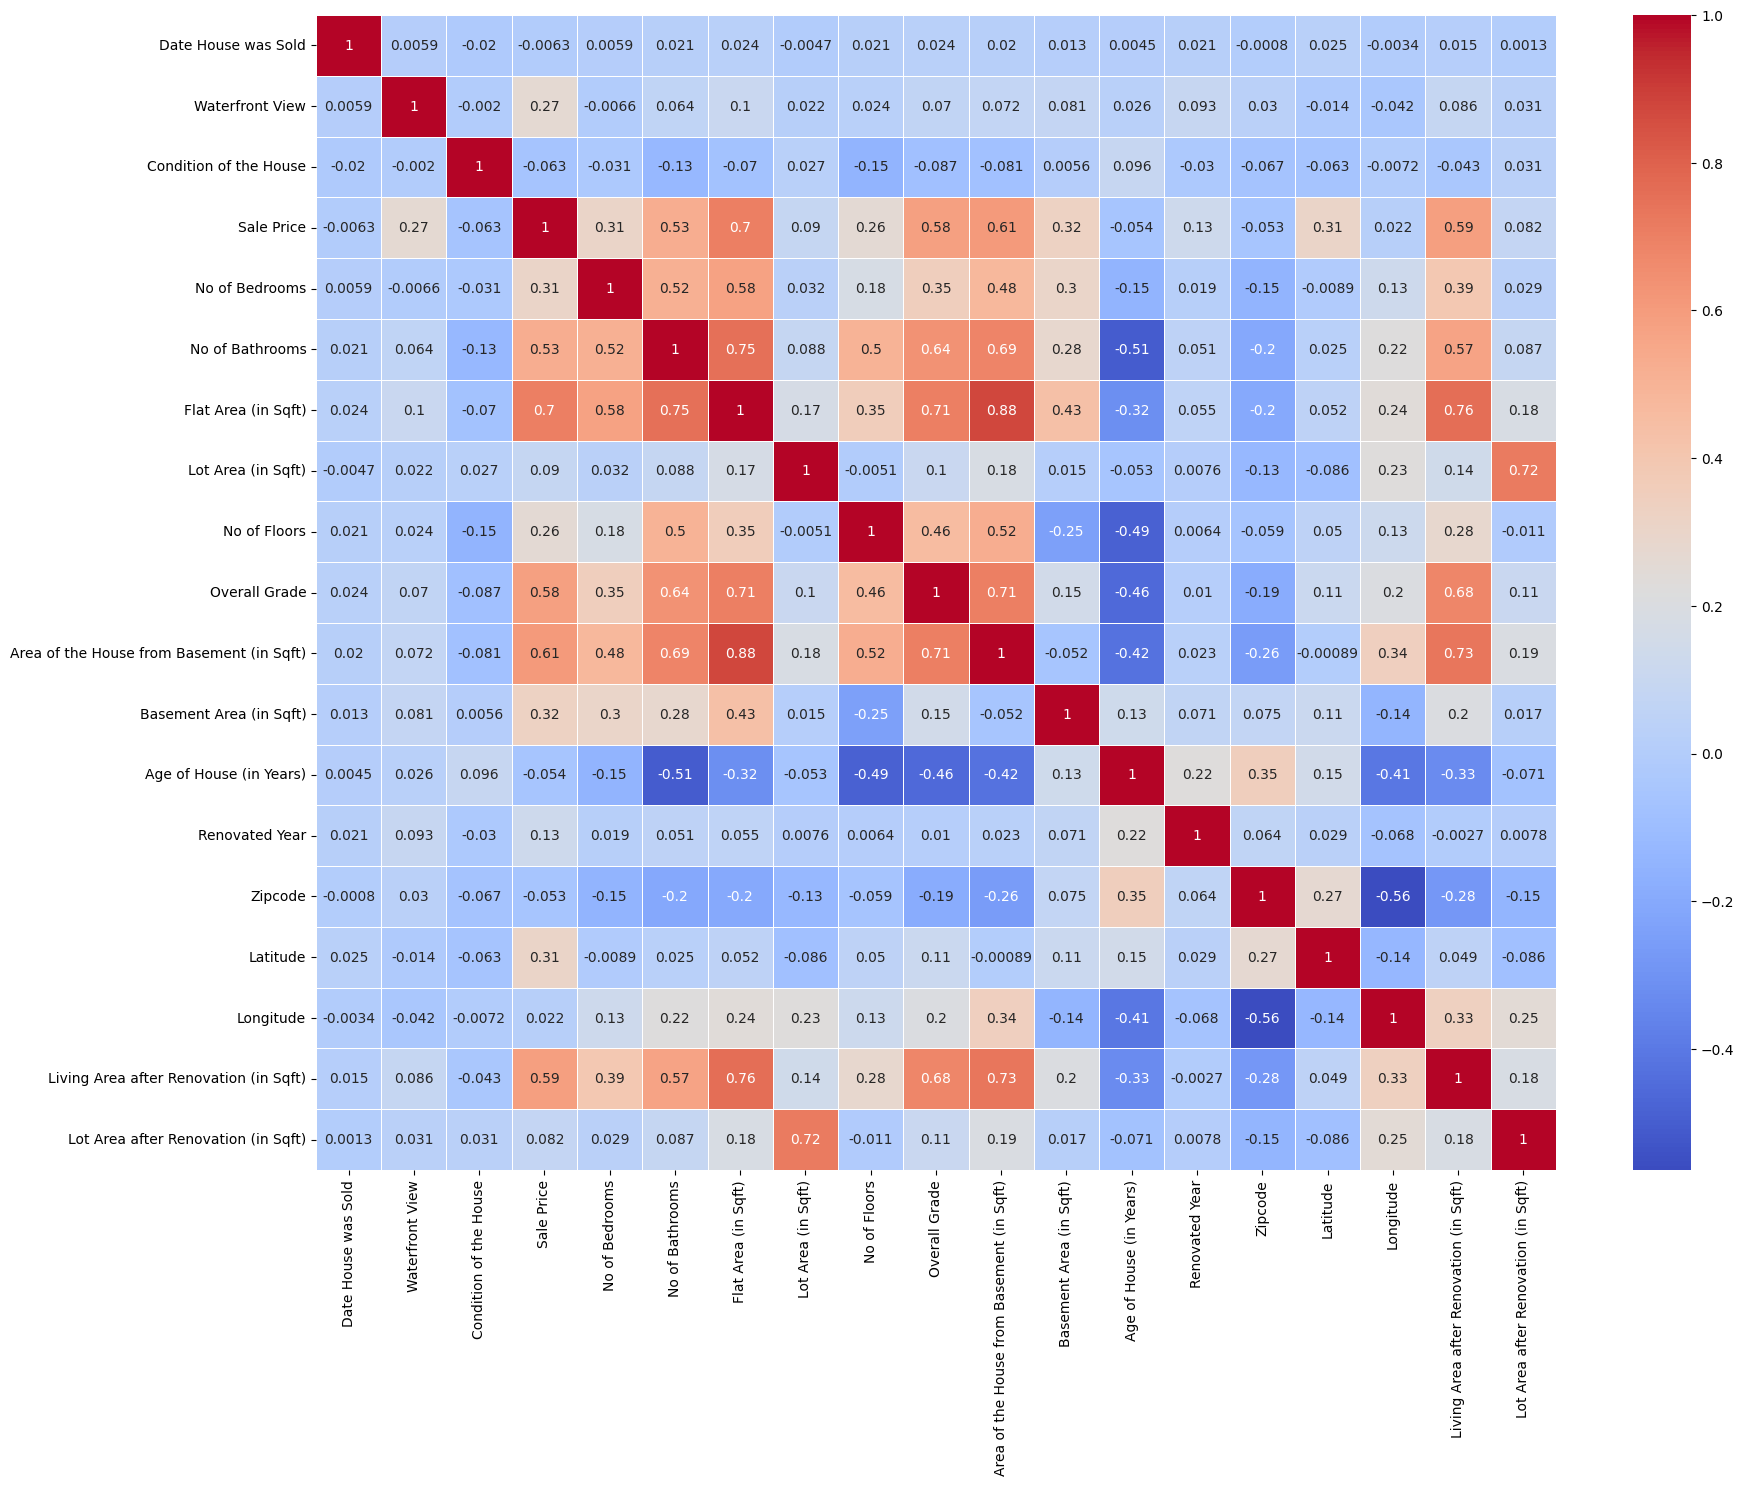

In [264]:
corr_result=df_imputed.corr()
plt.figure(figsize=(20,15))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5)
plt.show()

In [265]:
df_imputed.columns

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House',
       'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [266]:
#My target is Saleprice
#My absolute value is .7
corr_columns=["Flat Area (in Sqft)","Living Area after Renovation (in Sqft)","Area of the House from Basement (in Sqft)","Sale Price"]
#Remove other
df_imputed.drop(columns=df_imputed.columns.difference(corr_columns),inplace=True)

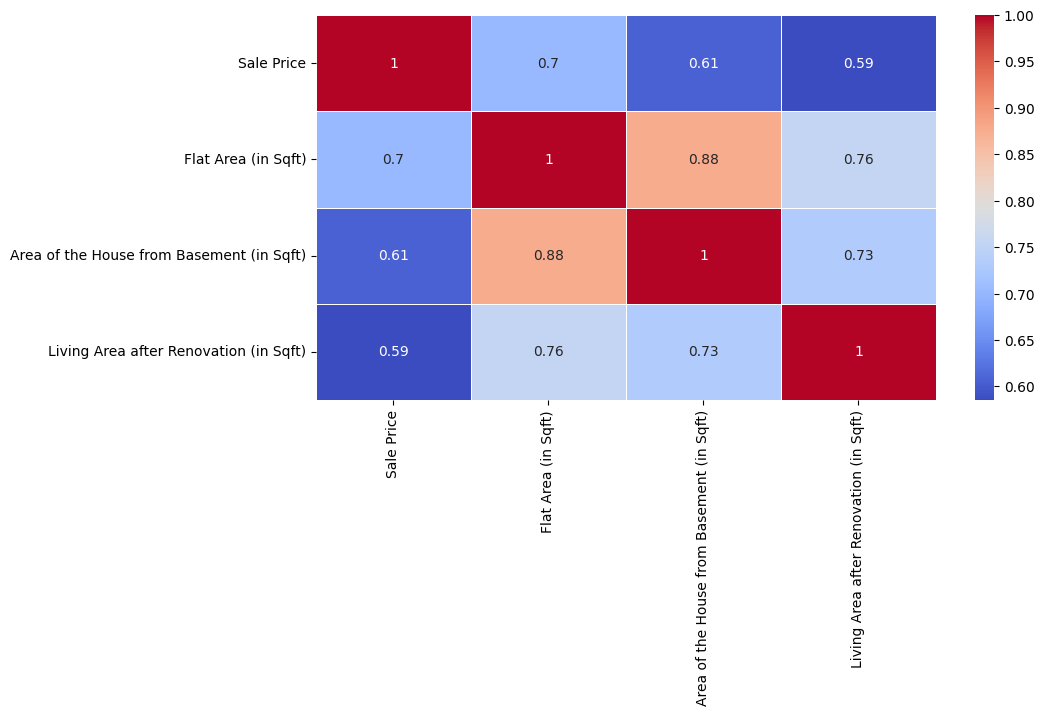

In [267]:
corr_result=df_imputed.corr()
plt.figure(figsize=(10,5))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5)
plt.show()

# **Outlier Removal**

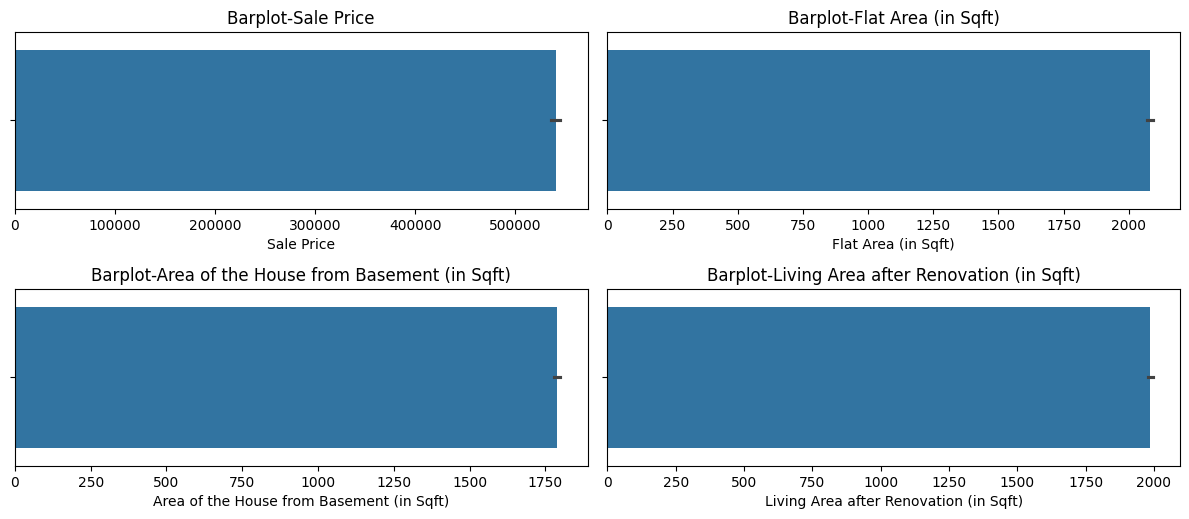

In [268]:
plt.figure(figsize=(12,10))
columns=df_imputed.columns

for i,col in enumerate(columns):
  plt.subplot(len(columns),2,i+1)
  sns.barplot(x=df[col])
  plt.title(f"Barplot-{col}")
plt.tight_layout()
plt.show()

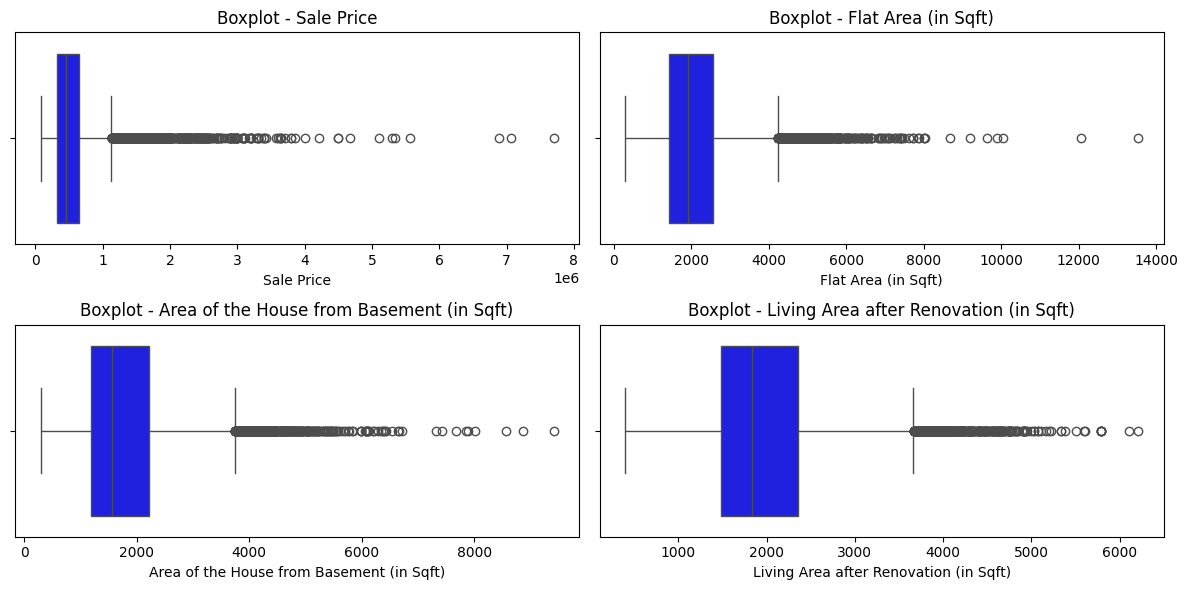

In [269]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Scale figure size dynamically based on the number of rows
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Use boxplot to highlight outliers (represented as individual dots)
    sns.boxplot(x=df_imputed[col], color='blue')
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

## **Fixing Outliers**

In [270]:
df_imputed.columns

Index(['Sale Price', 'Flat Area (in Sqft)',
       'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)'],
      dtype='object')

In [271]:

#fixing the outliers

cols_with_outliers=['Sale Price', 'Flat Area (in Sqft)',
       'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)']

def fixCols():
  for col in cols_with_outliers:
    Q1=df_imputed[col].quantile(.25)
    Q3=df_imputed[col].quantile(.75)

    IQR=Q3-Q1

    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR

    initial_outlier=df_imputed[(df_imputed[col]<lower_bound)|(df_imputed[col]>upper_bound)]

    print(f"Outliers in {col} before treatment:",initial_outlier[col].count())
    print("Treating Outliers...")
    df_imputed[col]=df_imputed[col].clip(upper=upper_bound,lower=lower_bound)
    final_outlier=df_imputed[(df_imputed[col]<lower_bound)|(df_imputed[col]>upper_bound)]
    print(f"Outliers in {col} after treatment:",final_outlier[col].count())

fixCols()




Outliers in Sale Price before treatment: 1159
Treating Outliers...
Outliers in Sale Price after treatment: 0
Outliers in Flat Area (in Sqft) before treatment: 572
Treating Outliers...
Outliers in Flat Area (in Sqft) after treatment: 0
Outliers in Area of the House from Basement (in Sqft) before treatment: 610
Treating Outliers...
Outliers in Area of the House from Basement (in Sqft) after treatment: 0
Outliers in Living Area after Renovation (in Sqft) before treatment: 544
Treating Outliers...
Outliers in Living Area after Renovation (in Sqft) after treatment: 0


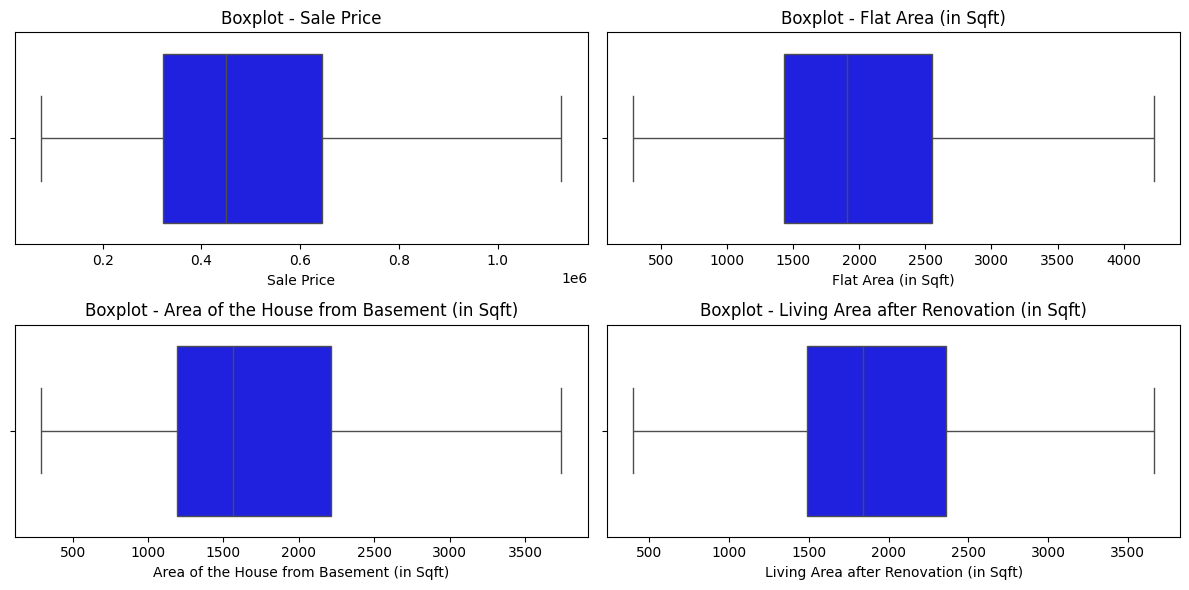

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Scale figure size dynamically based on the number of rows
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Use boxplot to highlight outliers (represented as individual dots)
    sns.boxplot(x=df_imputed[col], color='blue')
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

# **Train-Test Split**

In [273]:
# Using the outlier-treated and imputed df_imputed instead of df
X = df_imputed[['Flat Area (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Living Area after Renovation (in Sqft)']]
y = df_imputed['Sale Price']

In [274]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# **Scaling Numerical Variables**

In [275]:
scaler=StandardScaler()

In [276]:
X_train_scaled=scaler.fit_transform(X_train)

In [277]:
X_test_scaled=scaler.transform(X_test)

#**Model Building and Evaluation**

## Model training for regression



In [278]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [279]:
# SVM Regression
svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

SVR()

In [280]:
# Random Forest Regression
rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [281]:
# K-Nearest Neighbors Regression
from sklearn.neighbors import KNeighborsRegressor
knn_reg_model = KNeighborsRegressor(n_neighbors=5)
knn_reg_model.fit(X_train_scaled, y_train)

KNeighborsRegressor()

## model evaluation

In [282]:
reg_models = {
    "Linear Regression": lr_model,
    "SVM Regression": svr_model,
    "Random Forest": rf_reg_model,
    "KNN Regression": knn_reg_model
}

for name, model in reg_models.items():
    y_pred = model.predict(X_test_scaled)
    print(name + " Report\n")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))
    print("-" * 40)

Linear Regression Report

MAE: 139159.5683285499
MSE: 30684623766.018906
RMSE: 175170.27078251293
R2: 0.5208114769867014
----------------------------------------
SVM Regression Report

MAE: 195160.83058560852
MSE: 67798232876.167694
RMSE: 260380.93800462372
R2: -0.058775734797205326
----------------------------------------
Random Forest Report

MAE: 141393.19468542776
MSE: 33128061959.433605
RMSE: 182011.1588871232
R2: 0.4826533575355735
----------------------------------------
KNN Regression Report

MAE: 140413.1037936618
MSE: 32852153776.03704
RMSE: 181251.6310989698
R2: 0.48696209652801625
----------------------------------------


In [283]:
# saving best model
best_model = rf_reg_model

with open("best_model.pkl", "wb") as file:
    joblib.dump(best_model, file)

with open("best_model.pkl", "rb") as file:
    best_model = joblib.load(file)

y_pred = best_model.predict(X_test_scaled)